First part of the human pi investigation, focusing on genes and the distribution of diversity on chromosome X.
Also a comparison to reference X/A ratios.

In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

In [2]:
table_desc = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC.tsv"
metadata_path = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"

metadata_table = pd.read_csv(table_desc, sep="\t")

metadata_20x_filt = metadata_table.loc[(metadata_table.finalQC != "fail")
                              & (metadata_table.cov_chrA >= 20)
                              & (metadata_table.remove_as_relative != True)
                              & (metadata_table.remove_manual != True)
                              & (~metadata_table.ID.str.startswith("SAMEA11633"))
                             ]

In [3]:
metadata_20x_filt

,ID,ID_PGDP,group,family,genus,species,subspecies,species_full,species_short,species_genotyping,...,reason,finalQC,Kuderna_AB_QC,Kuderna_COV_QC,relatives,remove_as_relative,generation,founder,remove_manual,pedigree_source
0,PD_0028,PD_0028,OWM,Cercopithecidae,Allenopithecus,nigroviridis,ssp,Allenopithecus_nigroviridis_ssp,A.nigroviridis_ssp,Allenopithecus_nigroviridis_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PD_0126,PD_0126,OWM,Cercopithecidae,Allenopithecus,nigroviridis,ssp,Allenopithecus_nigroviridis_ssp,A.nigroviridis_ssp,Allenopithecus_nigroviridis_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SAMN15801446,SAMN15801446,OWM,Cercopithecidae,Allenopithecus,nigroviridis,ssp,Allenopithecus_nigroviridis_ssp,A.nigroviridis_ssp,Allenopithecus_nigroviridis_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PD_0798,PD_0798,PLA,Aotidae,Aotus,azarai,ssp,Aotus_azarai_ssp,A.azarai_ssp,Aotus_azarai_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PD_0799,PD_0799,PLA,Aotidae,Aotus,azarai,ssp,Aotus_azarai_ssp,A.azarai_ssp,Aotus_azarai_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3229,SAMEA112483311,SAMEA112483311,OWM,Cercopithecidae,Trachypithecus,vetulus,ssp,Trachypithecus_vetulus_ssp,T.vetulus_ssp,Trachypithecus_vetulus_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3230,SAMEA112483315,SAMEA112483315,OWM,Cercopithecidae,Trachypithecus,vetulus,ssp,Trachypithecus_vetulus_ssp,T.vetulus_ssp,Trachypithecus_vetulus_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3231,PD_0604,PD_0604,STR,Lemuridae,Varecia,rubra,ssp,Varecia_rubra_ssp,V.rubra_ssp,Varecia_rubra_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3235,PD_0621,PD_0621,STR,Lemuridae,Varecia,variegata,ssp,Varecia_variegata_ssp,V.variegata_ssp,Varecia_variegata_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
count_sub = metadata_20x_filt.loc[~metadata_20x_filt.cov_chrX.isna()][["gSEX", "group", "species_genotyping", "species"]].value_counts().reset_index()
used_species = count_sub.loc[(count_sub.gSEX == "F") | ((count_sub.gSEX == "M") & (count_sub["count"] >= 2))].species_genotyping.unique()

In [5]:
metadata_20x_filt.loc[metadata_20x_filt.species_genotyping == "Macaca_fuscata_ssp"].reference.iloc[0]

'Macaca_mulatta'

In [6]:
used_species

array(['Macaca_fascicularis_ssp', 'Pan_troglodytes_ssp',
       'Papio_anubis_ssp', 'Macaca_mulatta_ssp', 'Macaca_fuscata_ssp',
       'Papio_cynocephalus_ssp', 'Gorilla_gorilla_ssp',
       'Papio_hamadryas_ssp', 'Macaca_nemestrina_ssp', 'Papio_kindae_ssp',
       'Gorilla_beringei_ssp', 'Pan_paniscus_ssp', 'Sapajus_apella_ssp',
       'Pongo_abelii_ssp', 'Pongo_pygmaeus_ssp', 'Alouatta_seniculus_ssp',
       'Cacajao_calvus_ssp', 'Macaca_silenus_ssp', 'Macaca_radiata_ssp',
       'Aotus_nancymaae_ssp', 'Microcebus_murinus_ssp',
       'Aotus_azarai_ssp', 'Saimiri_cassiquiarensis_ssp',
       'Papio_papio_ssp', 'Hoolock_hoolock_ssp', 'Saimiri_ustus_ssp',
       'Trachypithecus_francoisi_ssp', 'Macaca_tonkeana_ssp',
       'Nycticebus_bengalensis_ssp', 'Macaca_arctoides_ssp',
       'Daubentonia_madagascariensis_ssp', 'Ateles_chamek_ssp',
       'Trachypithecus_poliocephalus_ssp', 'Theropithecus_gelada_ssp',
       'Cercocebus_atys_ssp', 'Papio_ursinus_ssp',
       'Cheracebus_lugens_s

In [7]:
pi_df_paths = glob.glob('../results/human_window_stats_20x_inds/*_25kb_pi_annotated.txt')
len(pi_df_paths)

212

In [8]:
df_l, unlifted_species = [], []
for s in used_species:
    # Read het df
    pi_df_path = "../results/human_window_stats_20x_inds/{}_25kb_pi_annotated.txt".format(s)
    if os.path.exists(pi_df_path):
        pi_df = pd.read_csv(pi_df_path, sep="\t")
    else:
        unlifted_species.append(s)
        continue
    df_l.append(pi_df)
all_pi_df = pd.concat(df_l)

In [9]:
# Number of species with some information on chrX.
lifted_species = all_pi_df.loc[(all_pi_df.chr_type == "chrX")].species.unique()
len(lifted_species)

168

In [10]:
# Species which have failed the conversion process
unlifted_species

['Macaca_radiata_ssp',
 'Saimiri_cassiquiarensis_ssp',
 'Hoolock_hoolock_ssp',
 'Saimiri_ustus_ssp',
 'Ateles_chamek_ssp',
 'Saimiri_macrodon_ssp',
 'Saimiri_boliviensis_ssp',
 'Semnopithecus_entellus_ssp',
 'Eulemur_flavifrons_ssp',
 'Lepilemur_septentrionalis_ssp',
 'Otolemur_crassicaudatus_ssp',
 'Lepilemur_ankaranensis_ssp',
 'Callimico_goeldii_ssp',
 'Otolemur_garnettii_ssp',
 'Galago_moholi_ssp',
 'Saimiri_sciureus_ssp',
 'Eulemur_coronatus_ssp',
 'Hoolock_leuconedys_ssp',
 'Eulemur_macaco_ssp',
 'Eulemur_rufifrons_ssp',
 'Galago_senegalensis_ssp',
 'Galagoides_demidoff_ssp',
 'Perodicticus_potto_ssp',
 'Presbytis_melalophos_ssp',
 'Colobus_angolensis_ssp']

In [11]:
# Worst performing species on chrX
all_pi_df.loc[(all_pi_df.chr_type == "chrX") & (~all_pi_df.pi.isna())
             &(all_pi_df.window_size <= 50000)]["species"].value_counts()[-20:]

species
Microcebus_tavaratra_ssp         779
Microcebus_jonahi_ssp            778
Nycticebus_bengalensis_ssp       729
Mirza_zaza_ssp                   715
Nycticebus_coucang_ssp           669
Xanthonycticebus_pygmaeus_ssp    643
Lemur_catta_ssp                  607
Avahi_peyrierasi_ssp             592
Hapalemur_meridionalis_ssp       558
Hapalemur_griseus_ssp            546
Prolemur_simus_ssp               545
Rhinopithecus_bieti_ssp          477
Mirza_coquereli_ssp              431
Indri_indri_ssp                  394
Loris_tardigradus_ssp            326
Loris_lydekkerianus_ssp          286
Arctocebus_calabarensis_ssp      185
Papio_cynocephalus_ssp           150
Pan_troglodytes_ssp               31
Rhinopithecus_roxellana_ssp       24
Name: count, dtype: int64

In [12]:
all_pi_df.loc[(all_pi_df.chr_type == "chrX")]["species"].value_counts()

species
Gorilla_gorilla_ssp            5343
Pan_paniscus_ssp               5305
Gorilla_beringei_ssp           5243
Pongo_pygmaeus_ssp             4970
Pongo_abelii_ssp               4930
                               ... 
Hapalemur_meridionalis_ssp     1064
Rhinopithecus_bieti_ssp         524
Papio_cynocephalus_ssp          182
Pan_troglodytes_ssp              33
Rhinopithecus_roxellana_ssp      30
Name: count, Length: 168, dtype: int64

In [13]:
all_pi_df.loc[(all_pi_df.chr_type == "chrX") & (all_pi_df.species == "Pan_troglodytes_ssp")]

,window_start,window_end,divergence,pi,chrom,chr_type,species,window_size,midpoint,window_100kb,genes,max_genes,largest_gene,largest_gene_cov
1038,152927949.0,152953597.0,32.1250,13.424296,NC_060947.1,chrX,Pan_troglodytes_ssp,25648.0,152940773.0,152900000,['GAB3'],1,GAB3,1.000000
1039,152953597.0,152978966.0,38.2750,13.466785,NC_060947.1,chrX,Pan_troglodytes_ssp,25369.0,152966281.5,152900000,['GAB3'],1,GAB3,1.000000
1040,152978966.0,153004858.0,55.3625,21.129767,NC_060947.1,chrX,Pan_troglodytes_ssp,25892.0,152991912.0,152900000,['GAB3' 'DKC1'],0,GAB3,0.327205
1041,153004858.0,153031535.0,47.2625,25.553662,NC_060947.1,chrX,Pan_troglodytes_ssp,26677.0,153018196.5,153000000,['MPP1' 'DKC1'],0,MPP1,0.597781
1042,153031535.0,153057102.0,46.8250,23.416645,NC_060947.1,chrX,Pan_troglodytes_ssp,25567.0,153044318.5,153000000,['MPP1'],0,MPP1,0.400829
1043,153057102.0,153082667.0,58.5000,26.025504,NC_060947.1,chrX,Pan_troglodytes_ssp,25565.0,153069884.5,153000000,['F8' 'SMIM9'],0,F8,0.339136
1044,153082667.0,153108208.0,66.7000,34.017163,NC_060947.1,chrX,Pan_troglodytes_ssp,25541.0,153095437.5,153000000,['F8'],1,F8,1.000000
1045,153108208.0,153140948.0,63.7125,29.399197,NC_060947.1,chrX,Pan_troglodytes_ssp,32740.0,153124578.0,153100000,['F8' 'F8A1' 'H2AB1'],1,F8,1.000000
1046,153140948.0,153166546.0,75.9500,41.258303,NC_060947.1,chrX,Pan_troglodytes_ssp,25598.0,153153747.0,153100000,['F8'],1,F8,1.000000
1047,153166546.0,153192104.0,64.9625,35.158695,NC_060947.1,chrX,Pan_troglodytes_ssp,25558.0,153179325.0,153100000,['F8'],1,F8,1.000000


<Axes: ylabel='Count'>

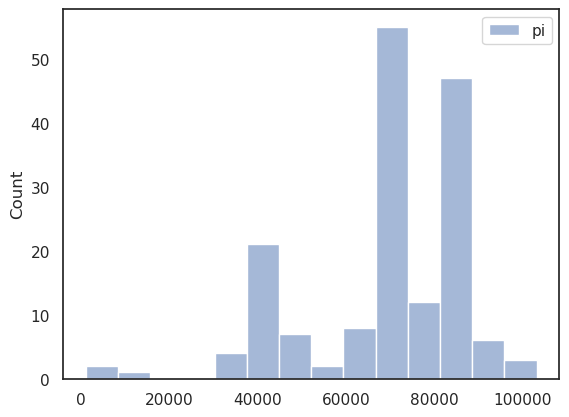

In [14]:
sns.histplot(all_pi_df.groupby(["species"])[["pi"]].count())

In [15]:
window_count = all_pi_df.groupby(["species"])[["pi"]].count()
window_count

,pi
species,
Allenopithecus_nigroviridis_ssp,83514
Allochrocebus_lhoesti_ssp,86632
Allochrocebus_preussi_ssp,85325
Alouatta_belzebul_ssp,64487
Alouatta_discolor_ssp,64322
...,...
Trachypithecus_pileatus_ssp,83840
Trachypithecus_poliocephalus_ssp,86544
Trachypithecus_vetulus_ssp,86017


<Axes: xlabel='count', ylabel='Count'>

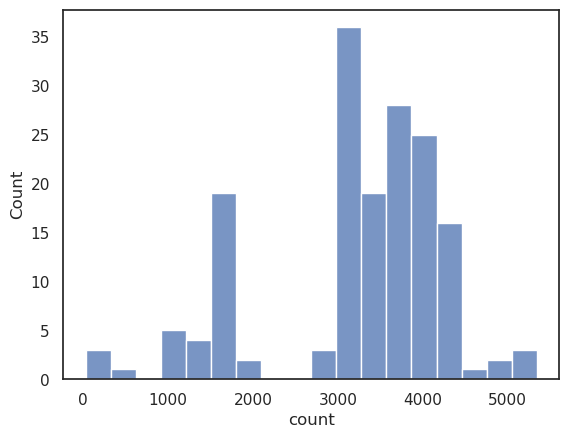

In [16]:
# I have a sneaking suspicion of a problem.
sns.histplot(all_pi_df.loc[(all_pi_df.chr_type == "chrX") & (~all_pi_df.pi.isna())].species.value_counts())

<Axes: xlabel='count', ylabel='Count'>

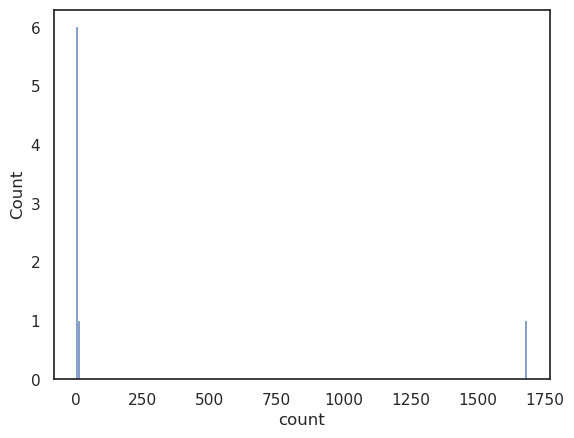

In [17]:
sns.histplot(all_pi_df.loc[(all_pi_df.chr_type == "chrX") & (all_pi_df.pi.isna())].species.value_counts())

In [18]:
all_pi_df.loc[(all_pi_df.chr_type == "chrX") & (all_pi_df.pi.isna())][["species"]].value_counts()

species                      
Cheirogaleus_medius_ssp          1683
Trachypithecus_pileatus_ssp         9
Rhinopithecus_strykeri_ssp          8
Semnopithecus_schistaceus_ssp       2
Xanthonycticebus_pygmaeus_ssp       2
Rhinopithecus_avunculus_ssp         1
Avahi_peyrierasi_ssp                1
Cebus_imitator_ssp                  1
Name: count, dtype: int64

In [19]:
# Calculating NA proportion for chrX.
called_count = all_pi_df.loc[(all_pi_df.chr_type == "chrX") & (~all_pi_df.pi.isna())].species.value_counts(dropna=False).reset_index()
na_count = all_pi_df.loc[(all_pi_df.chr_type == "chrX") & (all_pi_df.pi.isna())].species.value_counts(dropna=False).reset_index()

<Axes: xlabel='NaN proportion', ylabel='Count'>

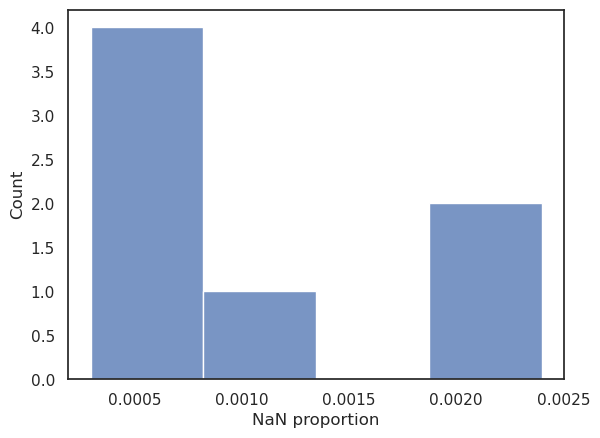

In [20]:
called_count["na_count"] = called_count.species.map(dict(zip(na_count.species, na_count["count"])))
called_count["NaN proportion"] = called_count["na_count"]/(called_count["na_count"]+called_count["count"])
sns.histplot(called_count, x="NaN proportion")

In [21]:
called_count.sort_values(by="NaN proportion", ascending=False)[:20]

,species,count,na_count,NaN proportion
61,Trachypithecus_pileatus_ssp,3744,9.0,0.002398
49,Rhinopithecus_strykeri_ssp,3827,8.0,0.002086
152,Xanthonycticebus_pygmaeus_ssp,1528,2.0,0.001307
153,Avahi_peyrierasi_ssp,1520,1.0,0.000657
59,Semnopithecus_schistaceus_ssp,3758,2.0,0.000532
103,Cebus_imitator_ssp,3226,1.0,0.000310
75,Rhinopithecus_avunculus_ssp,3375,1.0,0.000296
0,Gorilla_gorilla_ssp,5343,NaN,NaN
1,Pan_paniscus_ssp,5305,NaN,NaN
2,Gorilla_beringei_ssp,5243,NaN,NaN


In [22]:
# Calculating NA proportion for aut.
called_count = all_pi_df.loc[(all_pi_df.chr_type == "aut") & (~all_pi_df.pi.isna())].species.value_counts(dropna=False).reset_index()
na_count = all_pi_df.loc[(all_pi_df.chr_type == "aut") & (all_pi_df.pi.isna())].species.value_counts(dropna=False).reset_index()

In [23]:
called_count["na_count"] = called_count.species.map(dict(zip(na_count.species, na_count["count"])))
called_count["NaN proportion"] = called_count["na_count"]/(called_count["na_count"]+called_count["count"])
called_count

,species,count,na_count,NaN proportion
0,Gorilla_beringei_ssp,97993,NaN,NaN
1,Pongo_pygmaeus_ssp,94528,NaN,NaN
2,Pongo_abelii_ssp,93422,NaN,NaN
3,Symphalangus_syndactylus_ssp,88731,NaN,NaN
4,Nomascus_gabriellae_ssp,88369,NaN,NaN
...,...,...,...,...
163,Rhinopithecus_strykeri_ssp,30415,7.0,0.000230
164,Arctocebus_calabarensis_ssp,30169,1.0,0.000033
165,Rhinopithecus_bieti_ssp,7945,1.0,0.000126
166,Rhinopithecus_roxellana_ssp,2524,NaN,NaN


Calculating X/A for the ref.

In [24]:
df_l = []
for s in metadata_20x_filt.species_genotyping.unique():
    f_c = len(metadata_20x_filt.loc[metadata_20x_filt.gSEX == "F"])
    if f_c == 0:
        continue
    # Read het df
    pi_df_path = "../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)
    if os.path.exists("../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)):
        pi_df = pd.read_csv(pi_df_path, sep="\t")
    else:
        print("Not present:", s)
        continue
    df_l.append(pi_df)
all_pi_df_ref = pd.concat(df_l)

In [25]:
filt_pi_df = all_pi_df_ref.loc[all_pi_df_ref.callable_frac >= 0.5]
filt_pi_df["pi_adj"] = filt_pi_df.pi/filt_pi_df.callable_frac
mean_pi_df = filt_pi_df.loc[filt_pi_df.callable_frac >= 0.5].groupby(["species","chr_type"])[["pi", "pi_adj"]].mean()
mean_pi_df = mean_pi_df.reset_index().pivot(columns="chr_type", index="species", values="pi")
all_pi_df_aut = filt_pi_df.loc[filt_pi_df.chr_type == "aut"]
chrx_pi_df_aut = filt_pi_df.loc[filt_pi_df.chr_type == "chrX"]
mean_pi_df = mean_pi_df.reset_index()
mean_pi_df["CV_aut"] = (all_pi_df_aut.groupby(["species"])[["pi_adj"]].std() / all_pi_df_aut.groupby(["species"])[["pi_adj"]].mean()).reset_index()["pi_adj"]
CV_x_df = (chrx_pi_df_aut.groupby(["species"])[["pi_adj"]].std() / chrx_pi_df_aut.groupby(["species"])[["pi_adj"]].mean()).reset_index()
mean_pi_df["CV_x"] = mean_pi_df.species.map(dict(zip(CV_x_df.species, CV_x_df.pi_adj)))
mean_pi_df["Autosomal Pi per base"] = mean_pi_df.aut/100000
mean_pi_df["ChrX Pi per base"] = mean_pi_df.chrX/100000
mean_pi_df["X_a_ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df["X/A ratio"] = mean_pi_df.chrX/mean_pi_df.aut

/tmp/30036967/ipykernel_72437/1028071112.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filt_pi_df["pi_adj"] = filt_pi_df.pi/filt_pi_df.callable_frac


In [26]:
mean_pi_df

chr_type,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio
0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.443021,0.844265,0.001380,0.000761,0.551049,0.551049
1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.504078,1.012021,0.002712,0.000983,0.362366,0.362366
2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.687072,0.992060,0.002649,0.001059,0.399758,0.399758
3,Allochrocebus_solatus_ssp,302.877750,NaN,0.695848,NaN,0.003029,NaN,NaN,NaN
4,Alouatta_belzebul_ssp,510.169378,366.218989,0.262548,0.257281,0.005102,0.003662,0.717838,0.717838
...,...,...,...,...,...,...,...,...,...
246,Trachypithecus_poliocephalus_ssp,65.467857,38.032207,0.838183,0.759609,0.000655,0.000380,0.580929,0.580929
247,Trachypithecus_vetulus_ssp,232.827177,134.729050,0.462224,0.514592,0.002328,0.001347,0.578665,0.578665
248,Varecia_rubra_ssp,151.034928,NaN,0.768758,NaN,0.001510,NaN,NaN,NaN
249,Varecia_variegata_ssp,211.144432,120.002801,0.424734,0.613653,0.002111,0.001200,0.568345,0.568345


In [27]:
df_l, unlifted_species = [], []
for s in used_species:
    # Read het df
    pi_df_path = "../results/human_window_stats_20x_inds/{}_25kb_pi_annotated.txt".format(s)
    if os.path.exists(pi_df_path):
        pi_df = pd.read_csv(pi_df_path, sep="\t")
    else:
        unlifted_species.append(s)
        continue
    df_l.append(pi_df)
all_pi_df = pd.concat(df_l)

In [28]:
mean_pi_df_human = all_pi_df.loc[all_pi_df.window_size <= 50000].groupby(["species","chr_type"])[["pi"]].mean()
mean_pi_df_human = mean_pi_df_human.reset_index().pivot(columns="chr_type", index="species", values="pi")
all_pi_df_aut_human = all_pi_df.loc[all_pi_df.chr_type == "aut"]
chrx_pi_df_aut_human = all_pi_df.loc[all_pi_df.chr_type == "chrX"]

In [29]:
mean_pi_df_human = mean_pi_df_human.reset_index()
mean_pi_df_human["Autosomal Pi per base"] = mean_pi_df_human.aut/25000
mean_pi_df_human["ChrX Pi per base"] = mean_pi_df_human.chrX/25000
mean_pi_df_human["X_a_ratio"] = mean_pi_df_human.chrX/mean_pi_df_human.aut
mean_pi_df_human["X/A ratio"] = mean_pi_df_human.chrX/mean_pi_df_human.aut

In [30]:
mean_pi_df_human

chr_type,species,aut,chrX,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio
0,Allenopithecus_nigroviridis_ssp,36.855091,18.106086,0.001474,0.000724,0.491278,0.491278
1,Allochrocebus_lhoesti_ssp,74.783199,23.720306,0.002991,0.000949,0.317188,0.317188
2,Allochrocebus_preussi_ssp,74.079257,28.083265,0.002963,0.001123,0.379098,0.379098
3,Alouatta_belzebul_ssp,168.937197,116.396381,0.006757,0.004656,0.688992,0.688992
4,Alouatta_discolor_ssp,66.335827,31.218462,0.002653,0.001249,0.470612,0.470612
...,...,...,...,...,...,...,...
163,Trachypithecus_pileatus_ssp,31.588552,17.223361,0.001264,0.000689,0.545241,0.545241
164,Trachypithecus_poliocephalus_ssp,18.002286,10.467329,0.000720,0.000419,0.581444,0.581444
165,Trachypithecus_vetulus_ssp,65.659973,40.341281,0.002626,0.001614,0.614397,0.614397
166,Varecia_variegata_ssp,54.721772,28.497541,0.002189,0.001140,0.520772,0.520772


In [31]:
mean_pi_df

chr_type,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio
0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.443021,0.844265,0.001380,0.000761,0.551049,0.551049
1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.504078,1.012021,0.002712,0.000983,0.362366,0.362366
2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.687072,0.992060,0.002649,0.001059,0.399758,0.399758
3,Allochrocebus_solatus_ssp,302.877750,NaN,0.695848,NaN,0.003029,NaN,NaN,NaN
4,Alouatta_belzebul_ssp,510.169378,366.218989,0.262548,0.257281,0.005102,0.003662,0.717838,0.717838
...,...,...,...,...,...,...,...,...,...
246,Trachypithecus_poliocephalus_ssp,65.467857,38.032207,0.838183,0.759609,0.000655,0.000380,0.580929,0.580929
247,Trachypithecus_vetulus_ssp,232.827177,134.729050,0.462224,0.514592,0.002328,0.001347,0.578665,0.578665
248,Varecia_rubra_ssp,151.034928,NaN,0.768758,NaN,0.001510,NaN,NaN,NaN
249,Varecia_variegata_ssp,211.144432,120.002801,0.424734,0.613653,0.002111,0.001200,0.568345,0.568345


In [32]:
mean_pi_df["human_X/A"] = mean_pi_df.species.map(dict(zip(mean_pi_df_human["species"],
                                                          mean_pi_df_human["X_a_ratio"])))
mean_pi_df["human_A"] = mean_pi_df.species.map(dict(zip(mean_pi_df_human["species"],
                                                          mean_pi_df_human["Autosomal Pi per base"])))

<Axes: xlabel='X_a_ratio', ylabel='human_X/A'>

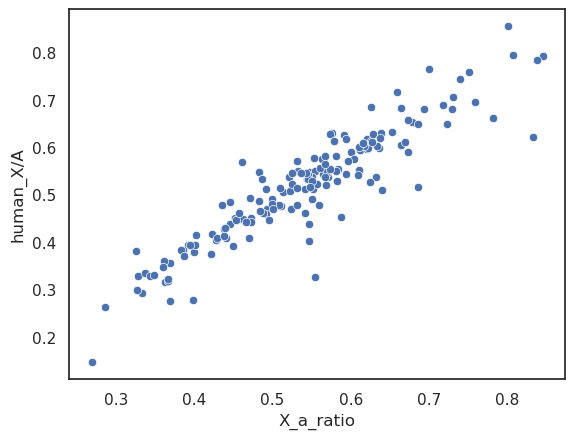

In [33]:
sns.scatterplot(mean_pi_df, x="X_a_ratio", y="human_X/A")

In [34]:
mean_pi_df.sort_values(by="X/A ratio")

chr_type,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,human_X/A,human_A
148,Mirza_coquereli_ssp,114.428173,30.785010,0.766252,1.406101,0.001144,0.000308,0.269033,0.269033,0.147484,0.002028
136,Mandrillus_leucophaeus_ssp,207.634820,59.318458,0.720180,1.152800,0.002076,0.000593,0.285686,0.285686,0.264833,0.002393
218,Saimiri_boliviensis_ssp,80.811061,23.506063,0.801899,1.429837,0.000808,0.000235,0.290877,0.290877,NaN,NaN
60,Cheirogaleus_medius_ssp,115.055240,36.537527,0.896765,1.192123,0.001151,0.000365,0.317565,0.317565,NaN,0.001214
61,Cheirogaleus_sibreei_ssp,328.918453,106.933523,0.587317,0.905936,0.003289,0.001069,0.325106,0.325106,0.382486,0.003782
...,...,...,...,...,...,...,...,...,...,...,...
236,Trachypithecus_ebenus_ssp,101.882676,NaN,0.852830,NaN,0.001019,NaN,NaN,NaN,NaN,NaN
239,Trachypithecus_germaini_ssp,187.173455,NaN,0.685890,NaN,0.001872,NaN,NaN,NaN,NaN,NaN
240,Trachypithecus_hatinhensis_ssp,94.488162,NaN,0.945117,NaN,0.000945,NaN,NaN,NaN,NaN,NaN
242,Trachypithecus_laotum_ssp,90.501394,NaN,1.017850,NaN,0.000905,NaN,NaN,NaN,NaN,NaN


In [35]:
mean_pi_df.sort_values(by="human_X/A")

chr_type,species,aut,chrX,CV_aut,CV_x,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,human_X/A,human_A
148,Mirza_coquereli_ssp,114.428173,30.785010,0.766252,1.406101,0.001144,0.000308,0.269033,0.269033,0.147484,0.002028
136,Mandrillus_leucophaeus_ssp,207.634820,59.318458,0.720180,1.152800,0.002076,0.000593,0.285686,0.285686,0.264833,0.002393
198,Propithecus_edwardsi_ssp,150.880844,55.577586,0.887117,1.495993,0.001509,0.000556,0.368354,0.368354,0.276655,0.001891
76,Eulemur_collaris_ssp,157.354667,62.701811,0.691496,1.277744,0.001574,0.000627,0.398474,0.398474,0.279669,0.001661
42,Cercocebus_chrysogaster_ssp,162.909983,54.271370,0.908869,1.265865,0.001629,0.000543,0.333137,0.333137,0.292382,0.001841
...,...,...,...,...,...,...,...,...,...,...,...
236,Trachypithecus_ebenus_ssp,101.882676,NaN,0.852830,NaN,0.001019,NaN,NaN,NaN,NaN,NaN
239,Trachypithecus_germaini_ssp,187.173455,NaN,0.685890,NaN,0.001872,NaN,NaN,NaN,NaN,NaN
240,Trachypithecus_hatinhensis_ssp,94.488162,NaN,0.945117,NaN,0.000945,NaN,NaN,NaN,NaN,NaN
242,Trachypithecus_laotum_ssp,90.501394,NaN,1.017850,NaN,0.000905,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='Autosomal Pi per base', ylabel='human_A'>

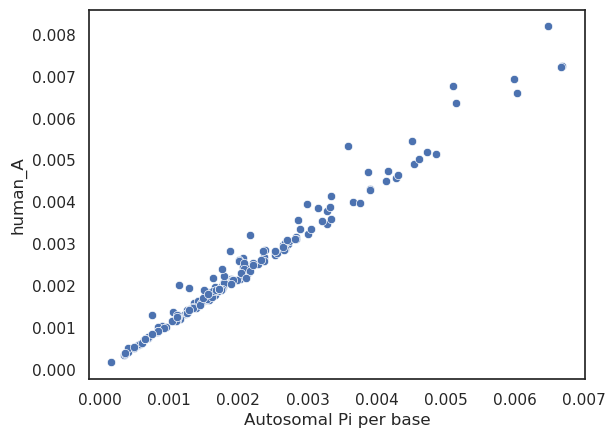

In [36]:
sns.scatterplot(mean_pi_df, x="Autosomal Pi per base", y="human_A")

In [37]:
mean_pi_df[["X_a_ratio", "human_X/A"]].corr()

chr_type,X_a_ratio,human_X/A
chr_type,,
X_a_ratio,1.000000,0.920073
human_X/A,0.920073,1.000000


In [38]:
mean_pi_df[["Autosomal Pi per base", "human_A"]].corr()

chr_type,Autosomal Pi per base,human_A
chr_type,,
Autosomal Pi per base,1.000000,0.988476
human_A,0.988476,1.000000


Checking the lowest hits for the all pi df.

In [39]:
filt_windows = all_pi_df.loc[all_pi_df.window_size <= 50000]
filt_windows

,window_start,window_end,divergence,pi,chrom,chr_type,species,window_size,midpoint,window_100kb,genes,max_genes,largest_gene,largest_gene_cov
1,364468.0,393940.0,798.469231,125.479293,NC_060925.1,aut,Macaca_fascicularis_ssp,29472.0,379204.0,300000,['NOC2L' 'SAMD11' 'KLHL17'],0,NOC2L,0.495046
2,393940.0,428539.0,522.669231,91.518324,NC_060925.1,aut,Macaca_fascicularis_ssp,34599.0,411239.5,400000,['PLEKHN1' 'PERM1'],0,PLEKHN1,0.232434
3,428539.0,465633.0,468.823077,66.692063,NC_060925.1,aut,Macaca_fascicularis_ssp,37094.0,447086.0,400000,['AGRN' 'HES4' 'ISG15'],0,AGRN,0.413382
4,465633.0,496424.0,872.307692,79.568333,NC_060925.1,aut,Macaca_fascicularis_ssp,30791.0,481028.5,400000,['AGRN'],0,AGRN,0.630476
5,496424.0,532883.0,517.069231,146.499521,NC_060925.1,aut,Macaca_fascicularis_ssp,36459.0,514653.5,500000,['C1orf159' 'RNF223'],0,C1orf159,0.237308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67962,153258626.0,153289252.0,173.000000,9.000000,NC_060947.1,chrX,Cercopithecus_roloway_ssp,30626.0,153273939.0,153200000,['FUNDC2' 'F8'],0,FUNDC2,0.846078
67963,153289252.0,153316723.0,134.000000,8.000000,NC_060947.1,chrX,Cercopithecus_roloway_ssp,27471.0,153302987.5,153300000,['BRCC3' 'CMC4' 'FUNDC2' 'MTCP1' 'BX470111.1'],0,BRCC3,0.319901
67964,153316723.0,153349762.0,191.000000,11.000000,NC_060947.1,chrX,Cercopithecus_roloway_ssp,33039.0,153333242.5,153300000,['BRCC3'],1,BRCC3,1.000000
67966,153423521.0,153463650.0,184.000000,36.000000,NC_060947.1,chrX,Cercopithecus_roloway_ssp,40129.0,153443585.5,153400000,['VBP1'],0,VBP1,0.459692


In [40]:
mean_midpoint = filt_windows.groupby(["species", "chr_type", "chrom", "window_100kb"])["pi"].mean()
mean_midpoint = mean_midpoint.reset_index().copy()
mean_across_species = mean_midpoint.groupby(["chr_type", "chrom", "window_100kb"])["pi"].mean().reset_index()
species_counted = mean_midpoint.groupby(["chr_type", "chrom", "window_100kb"])["pi"].count().reset_index()
mean_across_species["species_used"] = species_counted["pi"]

<Axes: xlabel='pi', ylabel='species_used'>

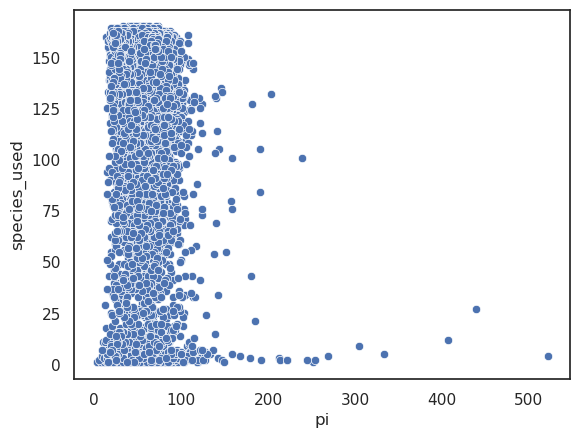

In [41]:
sns.scatterplot(mean_across_species, y="species_used", x="pi")

In [42]:
mean_across_species.loc[(mean_across_species.chr_type == "chrX") & (mean_across_species.species_used >= 50)]

,chr_type,chrom,window_100kb,pi,species_used
26239,chrX,NC_060947.1,2400000,49.772501,60
26241,chrX,NC_060947.1,2600000,50.130744,81
26248,chrX,NC_060947.1,3500000,39.973936,120
26249,chrX,NC_060947.1,3600000,41.110089,120
26254,chrX,NC_060947.1,4100000,49.820404,120
...,...,...,...,...,...
27668,chrX,NC_060947.1,153300000,18.870807,136
27669,chrX,NC_060947.1,153400000,19.614864,114
27670,chrX,NC_060947.1,153500000,15.247160,51
27672,chrX,NC_060947.1,153700000,14.501892,83


<Axes: xlabel='window_100kb', ylabel='pi'>

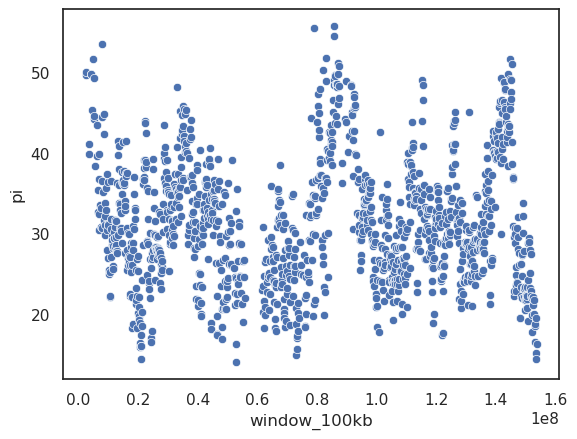

In [43]:
sns.scatterplot(mean_across_species.loc[(mean_across_species.chr_type == "chrX") & (mean_across_species.species_used >= 50)],
               x="window_100kb", y="pi")

<Axes: xlabel='species_used', ylabel='Count'>

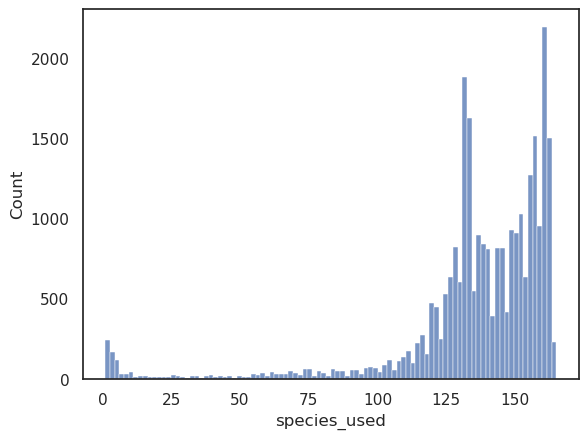

In [44]:
sns.histplot(mean_across_species, x="species_used")

In [45]:
mean_across_species.loc[(mean_across_species.chr_type == "chrX") &
                       (mean_across_species.species_used >= 20)].sort_values(by="pi")

,chr_type,chrom,window_100kb,pi,species_used
27149,chrX,NC_060947.1,100500000,12.771148,29
26737,chrX,NC_060947.1,52800000,14.062895,160
27148,chrX,NC_060947.1,100400000,14.369107,37
26421,chrX,NC_060947.1,20800000,14.454104,94
27672,chrX,NC_060947.1,153700000,14.501892,83
...,...,...,...,...,...
26255,chrX,NC_060947.1,4200000,54.581631,36
26963,chrX,NC_060947.1,78900000,55.546547,52
26268,chrX,NC_060947.1,5500000,55.697505,25
27030,chrX,NC_060947.1,85600000,55.785062,112


<Axes: xlabel='window_100kb', ylabel='pi'>

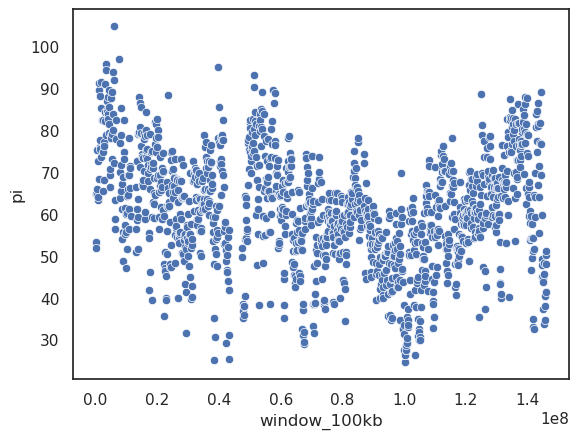

In [46]:
sns.scatterplot(mean_across_species.loc[(mean_across_species.chrom == "NC_060932.1") & (mean_across_species.species_used >= 50)],
               x="window_100kb", y="pi")